In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [4]:
transform = transforms.ToTensor()

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

img, label = cifar[0]  # one image
img = img.unsqueeze(0)  # (1, 3, 32, 32)

100%|██████████| 170M/170M [05:30<00:00, 516kB/s]  


In [6]:
def make_filter(kernel):
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)

    kernel = torch.tensor(kernel, dtype=torch.float32)

    # shape: (out_channels=1, in_channels=3, H, W)
    conv.weight.data = kernel.unsqueeze(0).repeat(1, 3, 1, 1)
    conv.weight.requires_grad = False

    return conv

In [7]:
vertical = [
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
]

In [8]:
horizontal = [
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
]

In [9]:
blur = (1/9) * np.ones((3, 3))

In [11]:
conv_v = make_filter(vertical)
conv_h = make_filter(horizontal)
conv_b = make_filter(blur)

In [12]:
with torch.no_grad():
    out_v = conv_v(img)
    out_h = conv_h(img)
    out_b = conv_b(img)

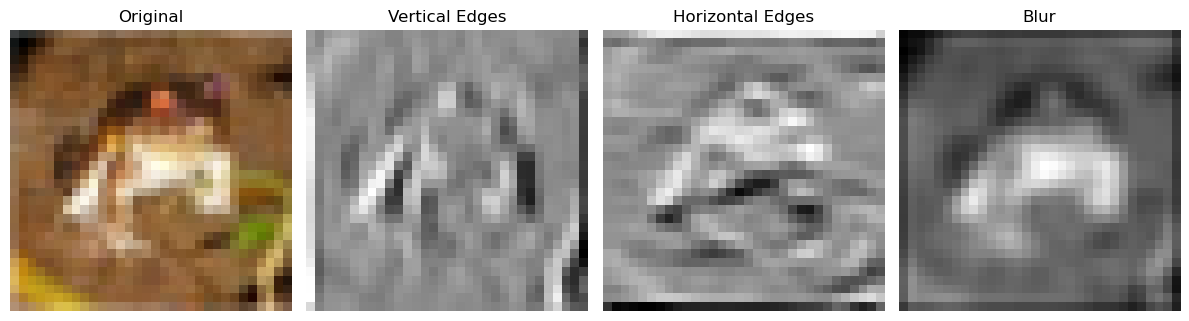

In [13]:
def show(tensor, ax, title):
    img = tensor.squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# original image (convert from C×H×W → H×W by averaging channels)
orig = img.squeeze().permute(1, 2, 0).numpy()
axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis("off")

show(out_v, axes[1], "Vertical Edges")
show(out_h, axes[2], "Horizontal Edges")
show(out_b, axes[3], "Blur")

plt.tight_layout()
plt.show()


What each filter does:

Vertical edge detector

Highlights vertical boundaries Detects left-right intensity changes

Horizontal edge detector

Highlights horizontal boundaries Detects top-bottom intensity changes

Blur filter

Averages neighboring pixels Removes noise and smooths the image

In [14]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        return x

In [15]:
x = torch.randn(8, 3, 32, 32)

In [16]:
model = TinyCNN()
out = model(x)
print(out.shape)

torch.Size([8, 32, 8, 8])


In [18]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

In [19]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )



        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)

In [20]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 1117354


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [22]:
def evaluate(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)

            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return loss_sum / total, 100 * correct / total

In [23]:
epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()

    running_loss, correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
          f"Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}%")

Epoch 1/15 | Train Loss 1.4142 | Val Loss 1.0019 | Train Acc 48.82% | Val Acc 63.94%
Epoch 2/15 | Train Loss 0.9720 | Val Loss 0.8155 | Train Acc 65.50% | Val Acc 70.98%
Epoch 3/15 | Train Loss 0.8321 | Val Loss 0.9803 | Train Acc 70.39% | Val Acc 68.30%
Epoch 4/15 | Train Loss 0.7423 | Val Loss 0.7071 | Train Acc 73.68% | Val Acc 74.94%
Epoch 5/15 | Train Loss 0.6711 | Val Loss 0.7322 | Train Acc 76.26% | Val Acc 74.54%
Epoch 6/15 | Train Loss 0.6145 | Val Loss 0.6451 | Train Acc 78.21% | Val Acc 77.72%
Epoch 7/15 | Train Loss 0.5664 | Val Loss 0.6580 | Train Acc 79.79% | Val Acc 77.46%
Epoch 8/15 | Train Loss 0.5196 | Val Loss 0.6342 | Train Acc 81.49% | Val Acc 78.26%
Epoch 9/15 | Train Loss 0.4787 | Val Loss 0.6424 | Train Acc 82.71% | Val Acc 78.56%
Epoch 10/15 | Train Loss 0.4493 | Val Loss 0.6906 | Train Acc 84.00% | Val Acc 77.00%
Epoch 11/15 | Train Loss 0.4149 | Val Loss 0.6986 | Train Acc 85.09% | Val Acc 77.36%
Epoch 12/15 | Train Loss 0.3779 | Val Loss 0.7265 | Train Acc 8

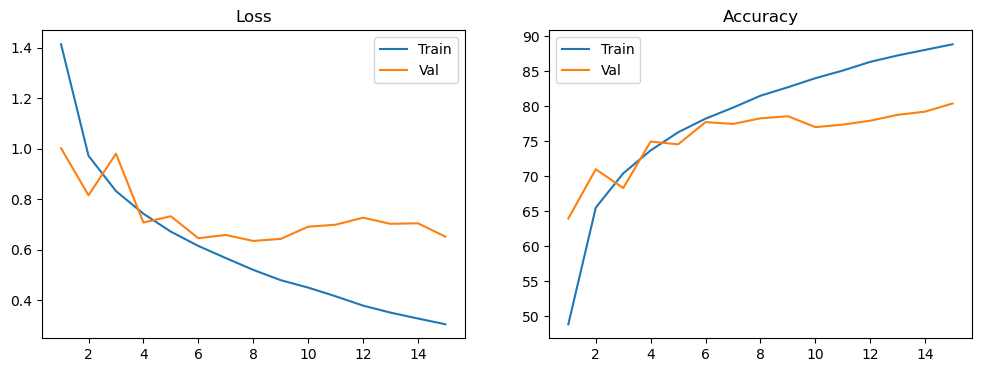

In [24]:

import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train")
plt.plot(epochs_range, val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, label="Train")
plt.plot(epochs_range, val_accs, label="Val")
plt.title("Accuracy")
plt.legend()

plt.show()

In [25]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [26]:
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [27]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

full_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_tf
)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_ds, val_ds = random_split(full_train, [train_size, val_size])

# IMPORTANT: override validation transform
val_ds.dataset.transform = val_tf

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

Data augmentation improved generalization by exposing the model to varied versions of the same images. This reduced overfitting, as shown by a smaller train-validation gap and improved validation accuracy. Although training accuracy decreased slightly, validation performance improved, indicating better robustness.
